In [25]:
from obspy import read
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from typing import Optional

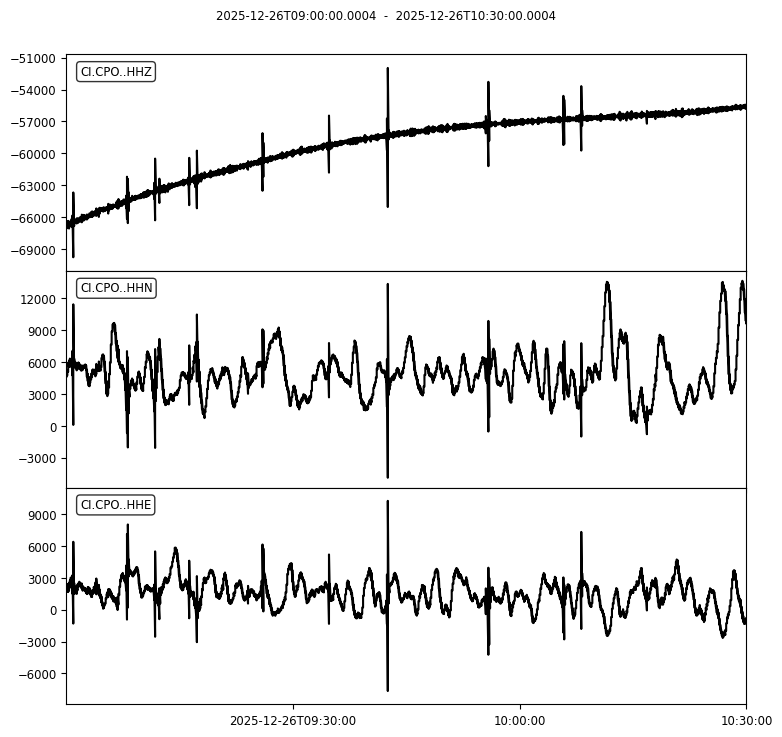

In [26]:
path1 = "./DEC26DATA/CI_WWF/*.mseed"
path2 = "./DEC26DATA/CI_CPO/*.mseed"

st = read(path2)
#st.write("combined_3C.mseed", format="MSEED")
st.plot();

In [44]:
def plot_st(st_matrix, f, title="Stockwell Transform"):
    plt.figure(figsize=(12, 8))

    extent = [0, st_matrix.shape[1], 0, f]
    st = np.abs(st_matrix)
    vmax = np.nanpercentile(st, 99)
    vmin = np.nanpercentile(st,1)


    plt.imshow(
        st,
        extent=extent,
        aspect='auto',
        origin='lower',
        cmap='viridis',
        vmin=vmin, 
        vmax=vmax,
    )

    plt.colorbar(label="Magnitude")
    plt.xlabel("Time")
    plt.ylabel("Frequency")

    plt.yscale("log")
    plt.ylim(max(0.05, 0), f)

    plt.title(title)
    plt.tight_layout()
    plt.show()


def stockwell(
    x: np.ndarray,
    dt: float,
    kmin: int = 0,
    kmax: Optional[int] = None,
    kstep: int = 1,
    k_bins: Optional[np.ndarray] = None,
    chunk_size: int = 256,
    mmap_path: Optional[str] = None,
    decimate: int = 1,
):
    real = np.float16
    out_dtype = np.complex64

    x = np.asarray(x, dtype=real)
    n = x.size

    if kmax is None:
        kmax = n // 2

    if k_bins is None:
        k_bins = np.arange(kmin, kmax + 1, kstep, dtype=int)

    num_k  = k_bins.size

    n_out = len(range(0, n, decimate))

    if mmap_path is None:
        S = np.zeros((num_k, n_out), dtype=out_dtype)
    else:
        S = np.memmap(mmap_path, mode="w+", dtype=out_dtype, shape=(num_k, n_out))

    row_cursor = (kmin==0)
    if kmin == 0:
        S[0, :] = np.mean(x).astype(real)
        k_bins = k_bins[1:]
        num_k-=1

    X = np.fft.fft(x)
    X2 = np.concatenate([X, X])

    t_front = np.arange(n, dtype=np.float32)**2
    t_back  = np.arange(-n, 0, dtype=np.float32)**2

    cols = np.arange(n)

    for i in range(0, num_k, chunk_size):

        k_batch = k_bins[i : i + chunk_size]
        B = k_batch.size
        if B == 0:
            break

        scale = -2.0 * (np.pi ** 2)
        scale = np.float16(scale) / (k_batch.astype(np.float32) ** 2)

        s = scale[:, None]

        gauss = np.exp(s * t_front[None, :], dtype=np.float32) + np.exp(s * t_back[None, :], dtype=np.float32)

        idx_start = k_batch[:, None] + cols[None, :]
        slices = X2[idx_start]

        rows = np.fft.ifft(slices * gauss, axis=1)
        S[row_cursor:row_cursor + B, :] = rows[:, ::decimate].astype(out_dtype, copy=False)
        row_cursor += B

    f_hz = kmax / (n * dt)

    return S, f_hz


In [28]:
HHE = st[0]
HHN = st[1]
HHW = st[2]

In [29]:
print(HHE.data.size)

540001


In [42]:
n = HHE.data.size
dt = 0.01

kmin = int(0.1 * n * dt)
kmax = int(20.0 * n * dt)

k_bins = np.unique(np.round(np.logspace(np.log10(kmin), np.log10(kmax), num=300)).astype(int))

S, f_hz = stockwell(HHE.data, dt=dt, k_bins=k_bins, kmax=kmax, decimate=20, chunk_size=500)

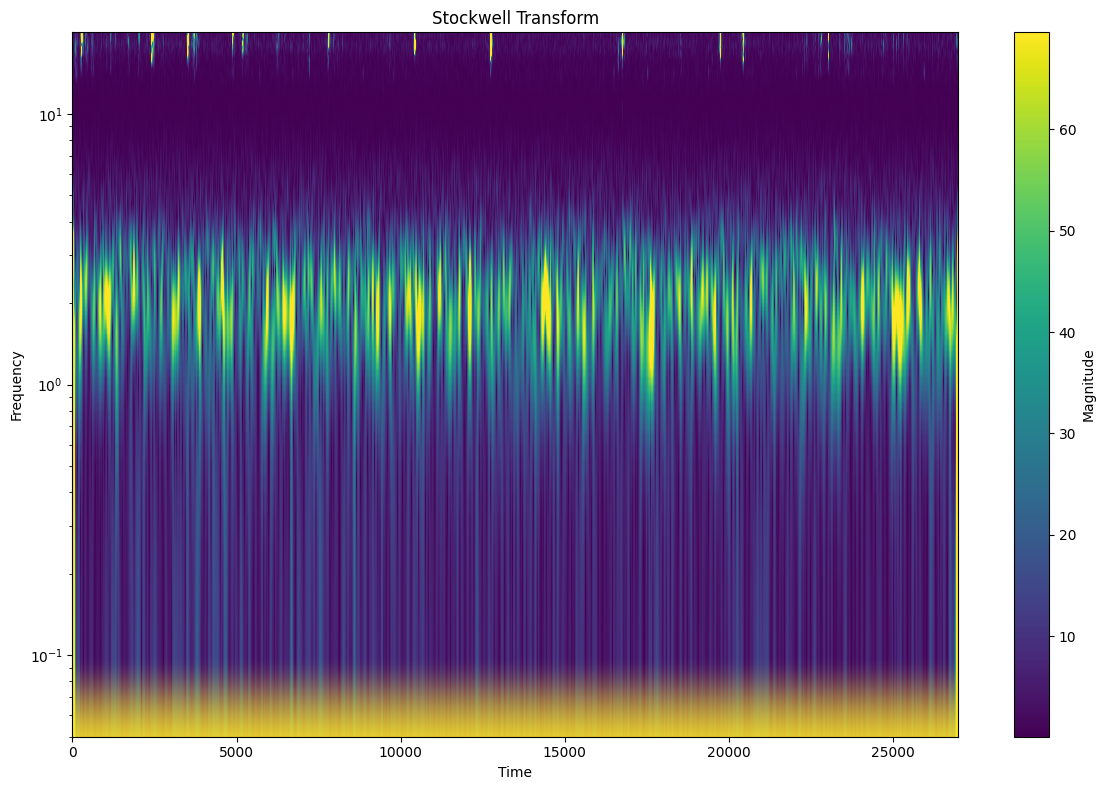

In [45]:
plot_st(S, f_hz)